In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 10.9 MB/s eta 0:00:00


In [3]:
import zipfile
import os

zip_path = "/content/Helmet Detection.v6-balanced-dataset.yolov8.zip"
extract_path = "/content/helmet_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

In [4]:
import os

for item in os.listdir("/content/helmet_dataset"):
    print(item)

README.roboflow.txt
test
valid
README.dataset.txt
train
data.yaml


In [5]:
import os

base_path = "/content/helmet_dataset"

for folder in ["train", "valid", "test"]:
    images_path = os.path.join(base_path, folder, "images")
    labels_path = os.path.join(base_path, folder, "labels")

    print(f"\n{folder.upper()}")
    print("Images:", len(os.listdir(images_path)))
    print("Labels:", len(os.listdir(labels_path)))


TRAIN
Images: 1070
Labels: 1070

VALID
Images: 309
Labels: 309

TEST
Images: 154
Labels: 154


In [6]:
yaml_path = "/content/helmet_dataset/data.yaml"

with open(yaml_path, "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['With Helmet', 'Without Helmet', 'licence']

roboflow:
  workspace: helmet-detection-cknan
  project: helmet-detection-v0zk7
  version: 6
  license: CC BY 4.0
  url: https://universe.roboflow.com/helmet-detection-cknan/helmet-detection-v0zk7/dataset/6


In [8]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/helmet_dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False, op

In [9]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

metrics = model.val(
    data="/content/helmet_dataset/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    plots=True
)

print("Test Precision:", metrics.box.mp)
print("Test Recall:", metrics.box.mr)
print("Test mAP50:", metrics.box.map50)
print("Test mAP50-95:", metrics.box.map)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 763.5±316.8 MB/s, size: 22.9 KB)
val: Scanning /content/helmet_dataset/test/labels... 154 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 154/154 2.1Kit/s 0.1s
val: New cache created: /content/helmet_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.9it/s 5.3s
                   all        154        237      0.778      0.752        0.8      0.467
           With Helmet         45         79      0.751      0.764      0.769      0.458
        Without Helmet         38         73      0.667      0.658      0.726      0.343
               licence         78         85      0.918      0.835      0.905      0.601
Speed: 5.0ms preprocess, 5.5ms inference, 0.0ms loss, 3.8ms postprocess p

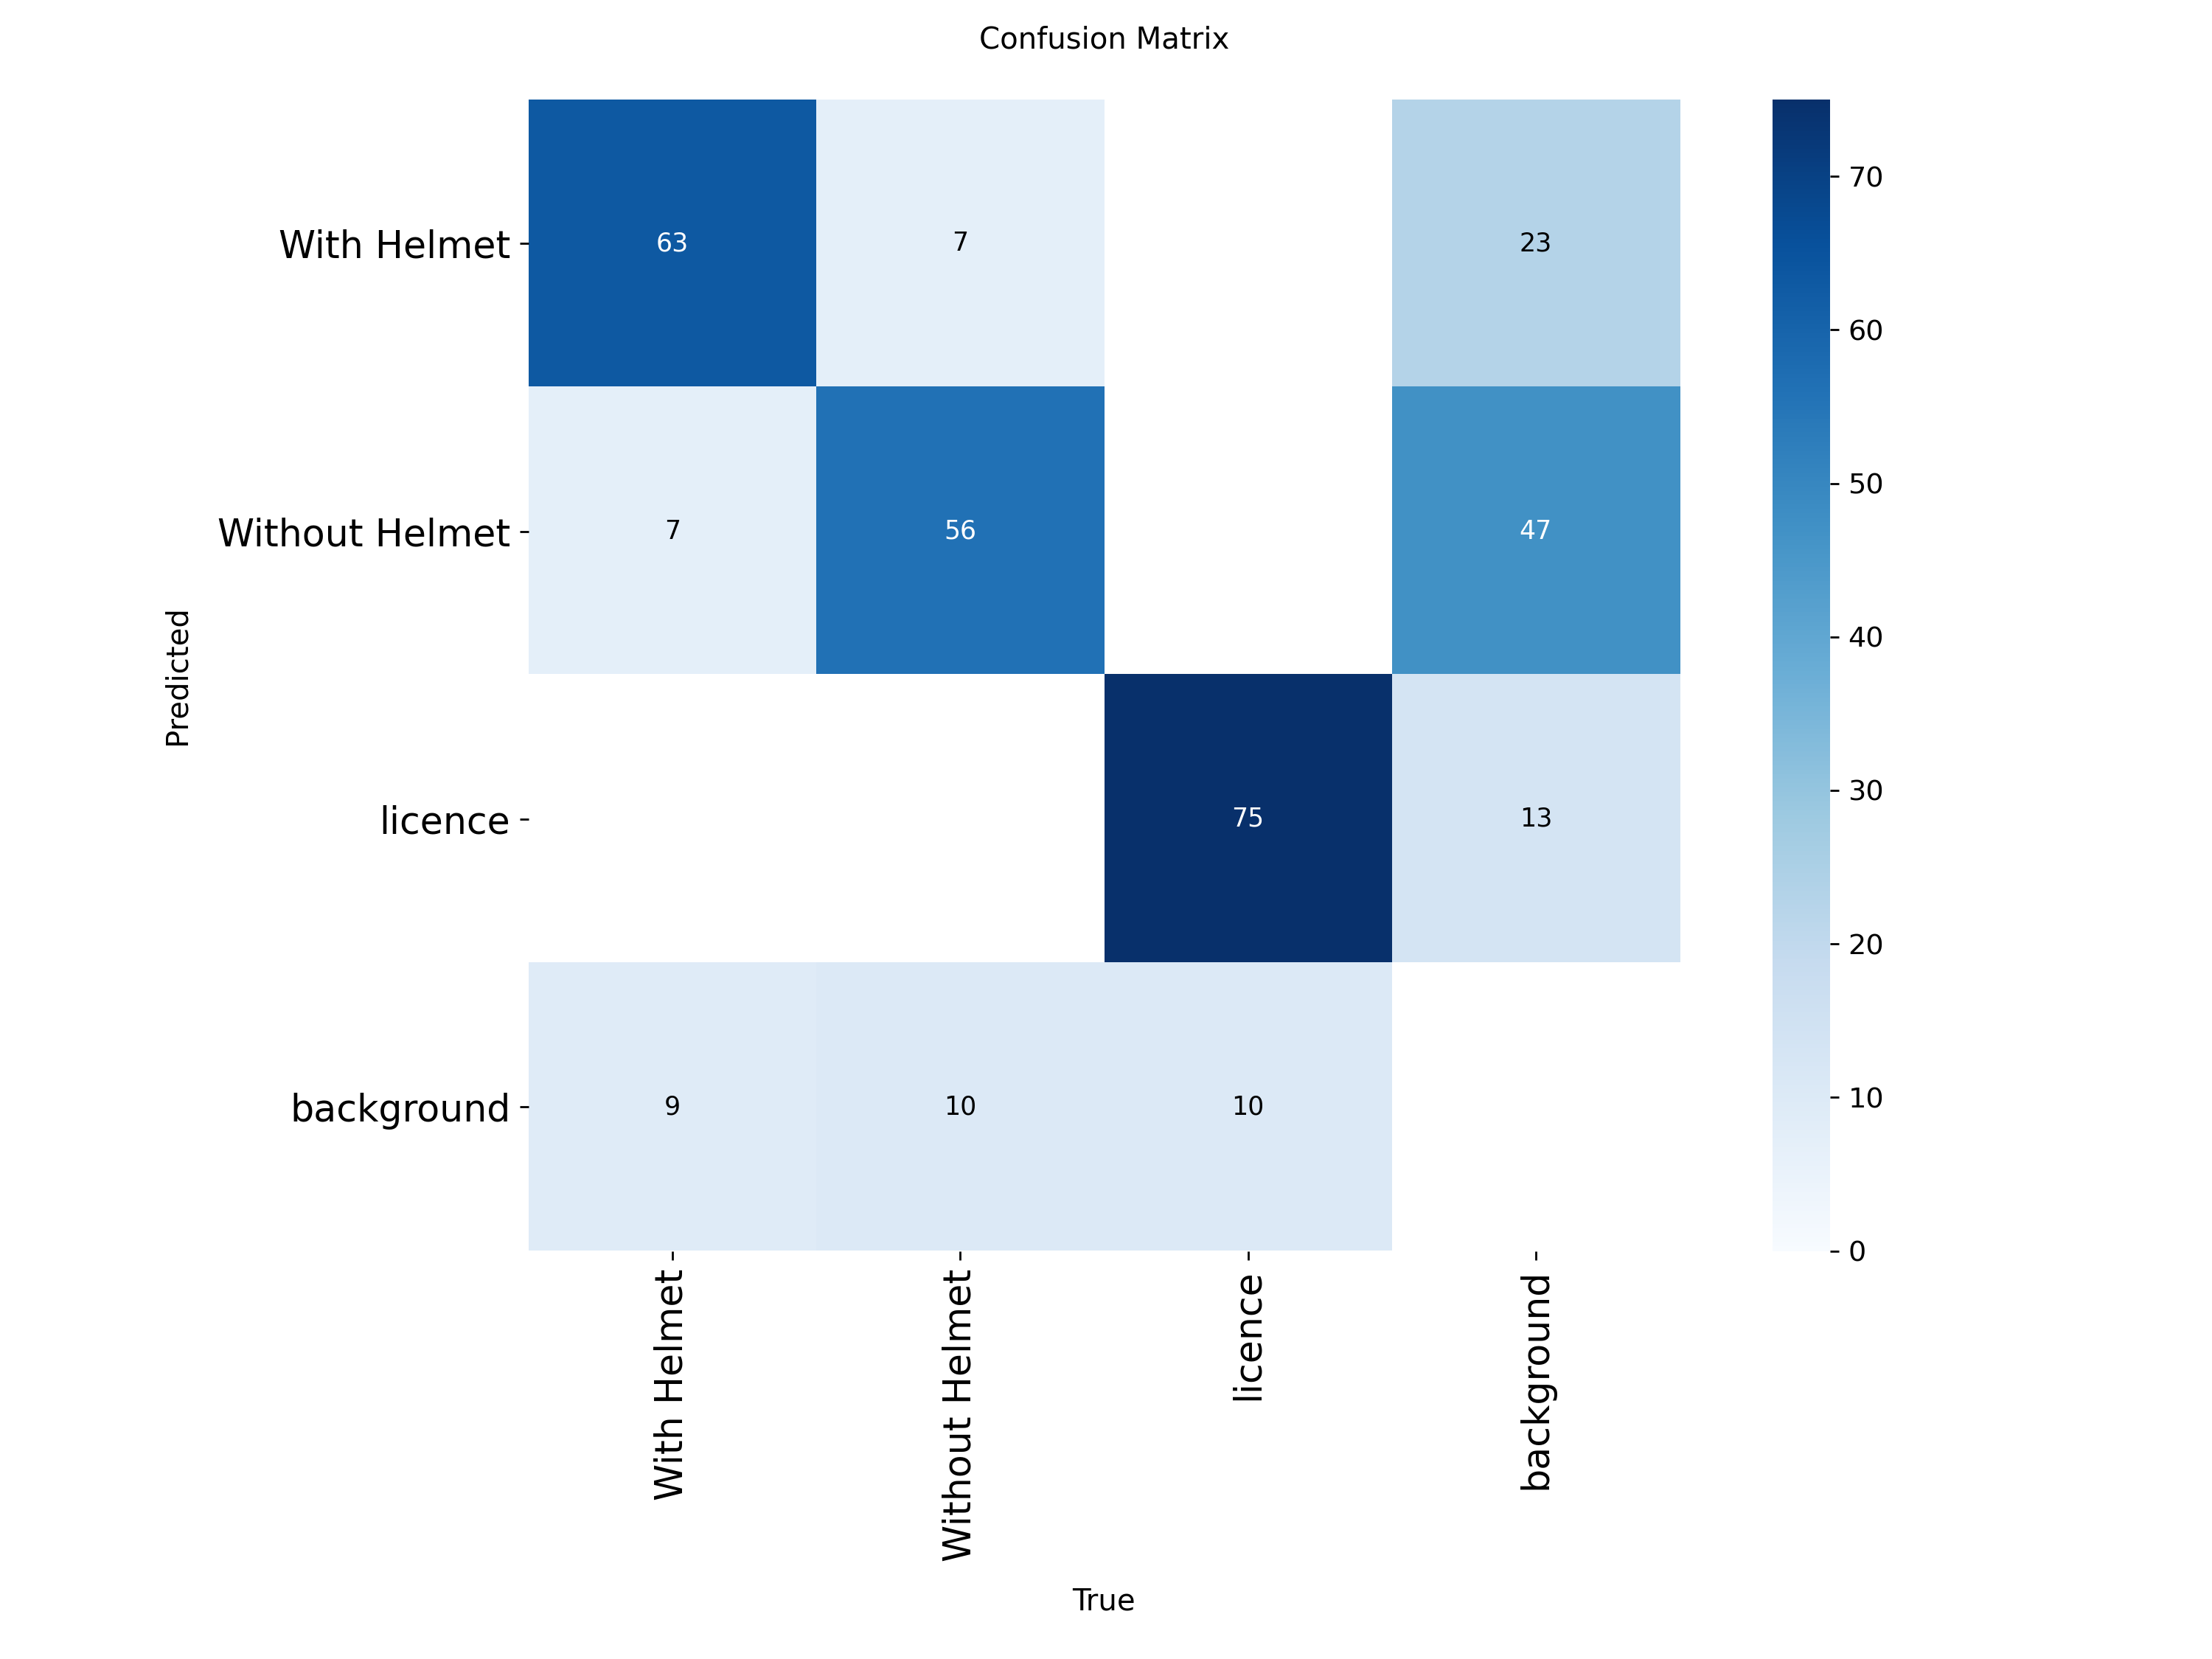

In [10]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/val-2/confusion_matrix.png"))

In [11]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

results = model.predict(
    source="/content/helmet_dataset/test/images",
    imgsz=640,
    conf=0.25,
    save=True
)

print("Predictions saved to:", results[0].save_dir)


image 1/154 /content/helmet_dataset/test/images/1-13-_jpg.rf.305c3e2e0b97079880ba67e3b6361e0c.jpg: 480x640 1 Without Helmet, 6.5ms
image 2/154 /content/helmet_dataset/test/images/1-17-_jpg.rf.df5a57d557fb7007c0e68c87125497c7.jpg: 512x640 2 Without Helmets, 71.5ms
image 3/154 /content/helmet_dataset/test/images/1-18-_png.rf.7d51f5cdbf6264a49048caf0614fbc9e.jpg: 416x640 2 Without Helmets, 89.5ms
image 4/154 /content/helmet_dataset/test/images/1-25-_jpg.rf.cc4aae596b0886371d2f96321290ce7d.jpg: 512x640 1 Without Helmet, 15.6ms
image 5/154 /content/helmet_dataset/test/images/1-45-_jpg.rf.861618fdfb21f05a3c445c6d3319bbbc.jpg: 448x640 2 With Helmets, 1 Without Helmet, 1 licence, 83.0ms
image 6/154 /content/helmet_dataset/test/images/1-5-_jpeg.rf.be2dc2f6ff6d1ce03547f76d9d843619.jpg: 352x640 7 Without Helmets, 81.9ms
image 7/154 /content/helmet_dataset/test/images/1-62-_jpg.rf.fbb0985aa7130c36ed9300cedcb413bf.jpg: 384x640 7 With Helmets, 2 Without Helmets, 135.3ms
image 8/154 /content/helmet_

Total prediction images: 154
xemay2096_jpg.rf.25a5f53307526fc6220b7a22b1d4c754.jpg


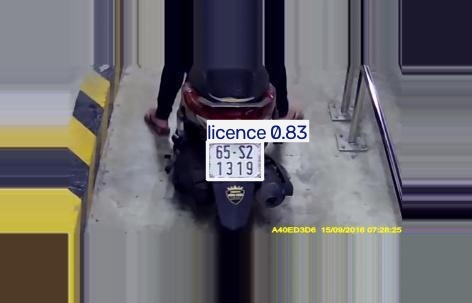

Cars207_png.rf.bdee2f04bb2b538b3ff5c64d37a54741.jpg


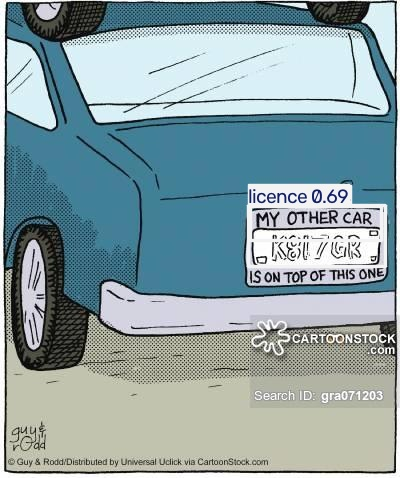

xemay854_jpg.rf.5d4788b7ecbbb36028730030905f5295.jpg


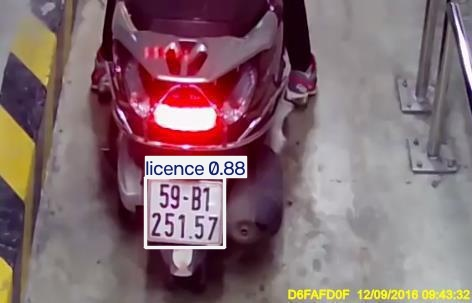

BikesHelmets326_png.rf.0a85ce02f7f9ba1f7fbf02f3fc5de15c.jpg


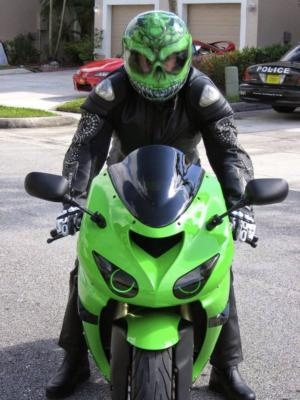

BikesHelmets619_png.rf.0bff5f1db126f57ef4ef423deeb26417.jpg


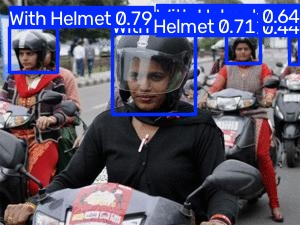

BikesHelmets679_png.rf.6afe6ce0eed714c2cef3d94d09a0af07.jpg


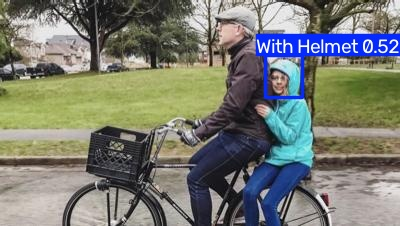

In [12]:
from IPython.display import Image, display
import os

prediction_dir = "/content/runs/detect/predict"

images = [
    f for f in os.listdir(prediction_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total prediction images:", len(images))

for img in images[:6]:
    print(img)
    display(Image(filename=os.path.join(prediction_dir, img), width=700))

In [14]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

metrics = model.val(
    data="/content/helmet_dataset/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    plots=True,
    save_json=False
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Results saved to:", metrics.save_dir)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 899.5±250.0 MB/s, size: 18.8 KB)
val: Scanning /content/helmet_dataset/test/labels.cache... 154 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 154/154 28.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.9it/s 5.1s
                   all        154        237      0.778      0.752        0.8      0.467
           With Helmet         45         79      0.751      0.764      0.769      0.458
        Without Helmet         38         73      0.667      0.658      0.726      0.343
               licence         78         85      0.918      0.835      0.905      0.601
Speed: 3.8ms preprocess, 4.5ms inference, 0.0ms loss, 5.2ms postprocess per image
Results saved to /content/runs/detect/val-3
Precis

confusion_matrix.png


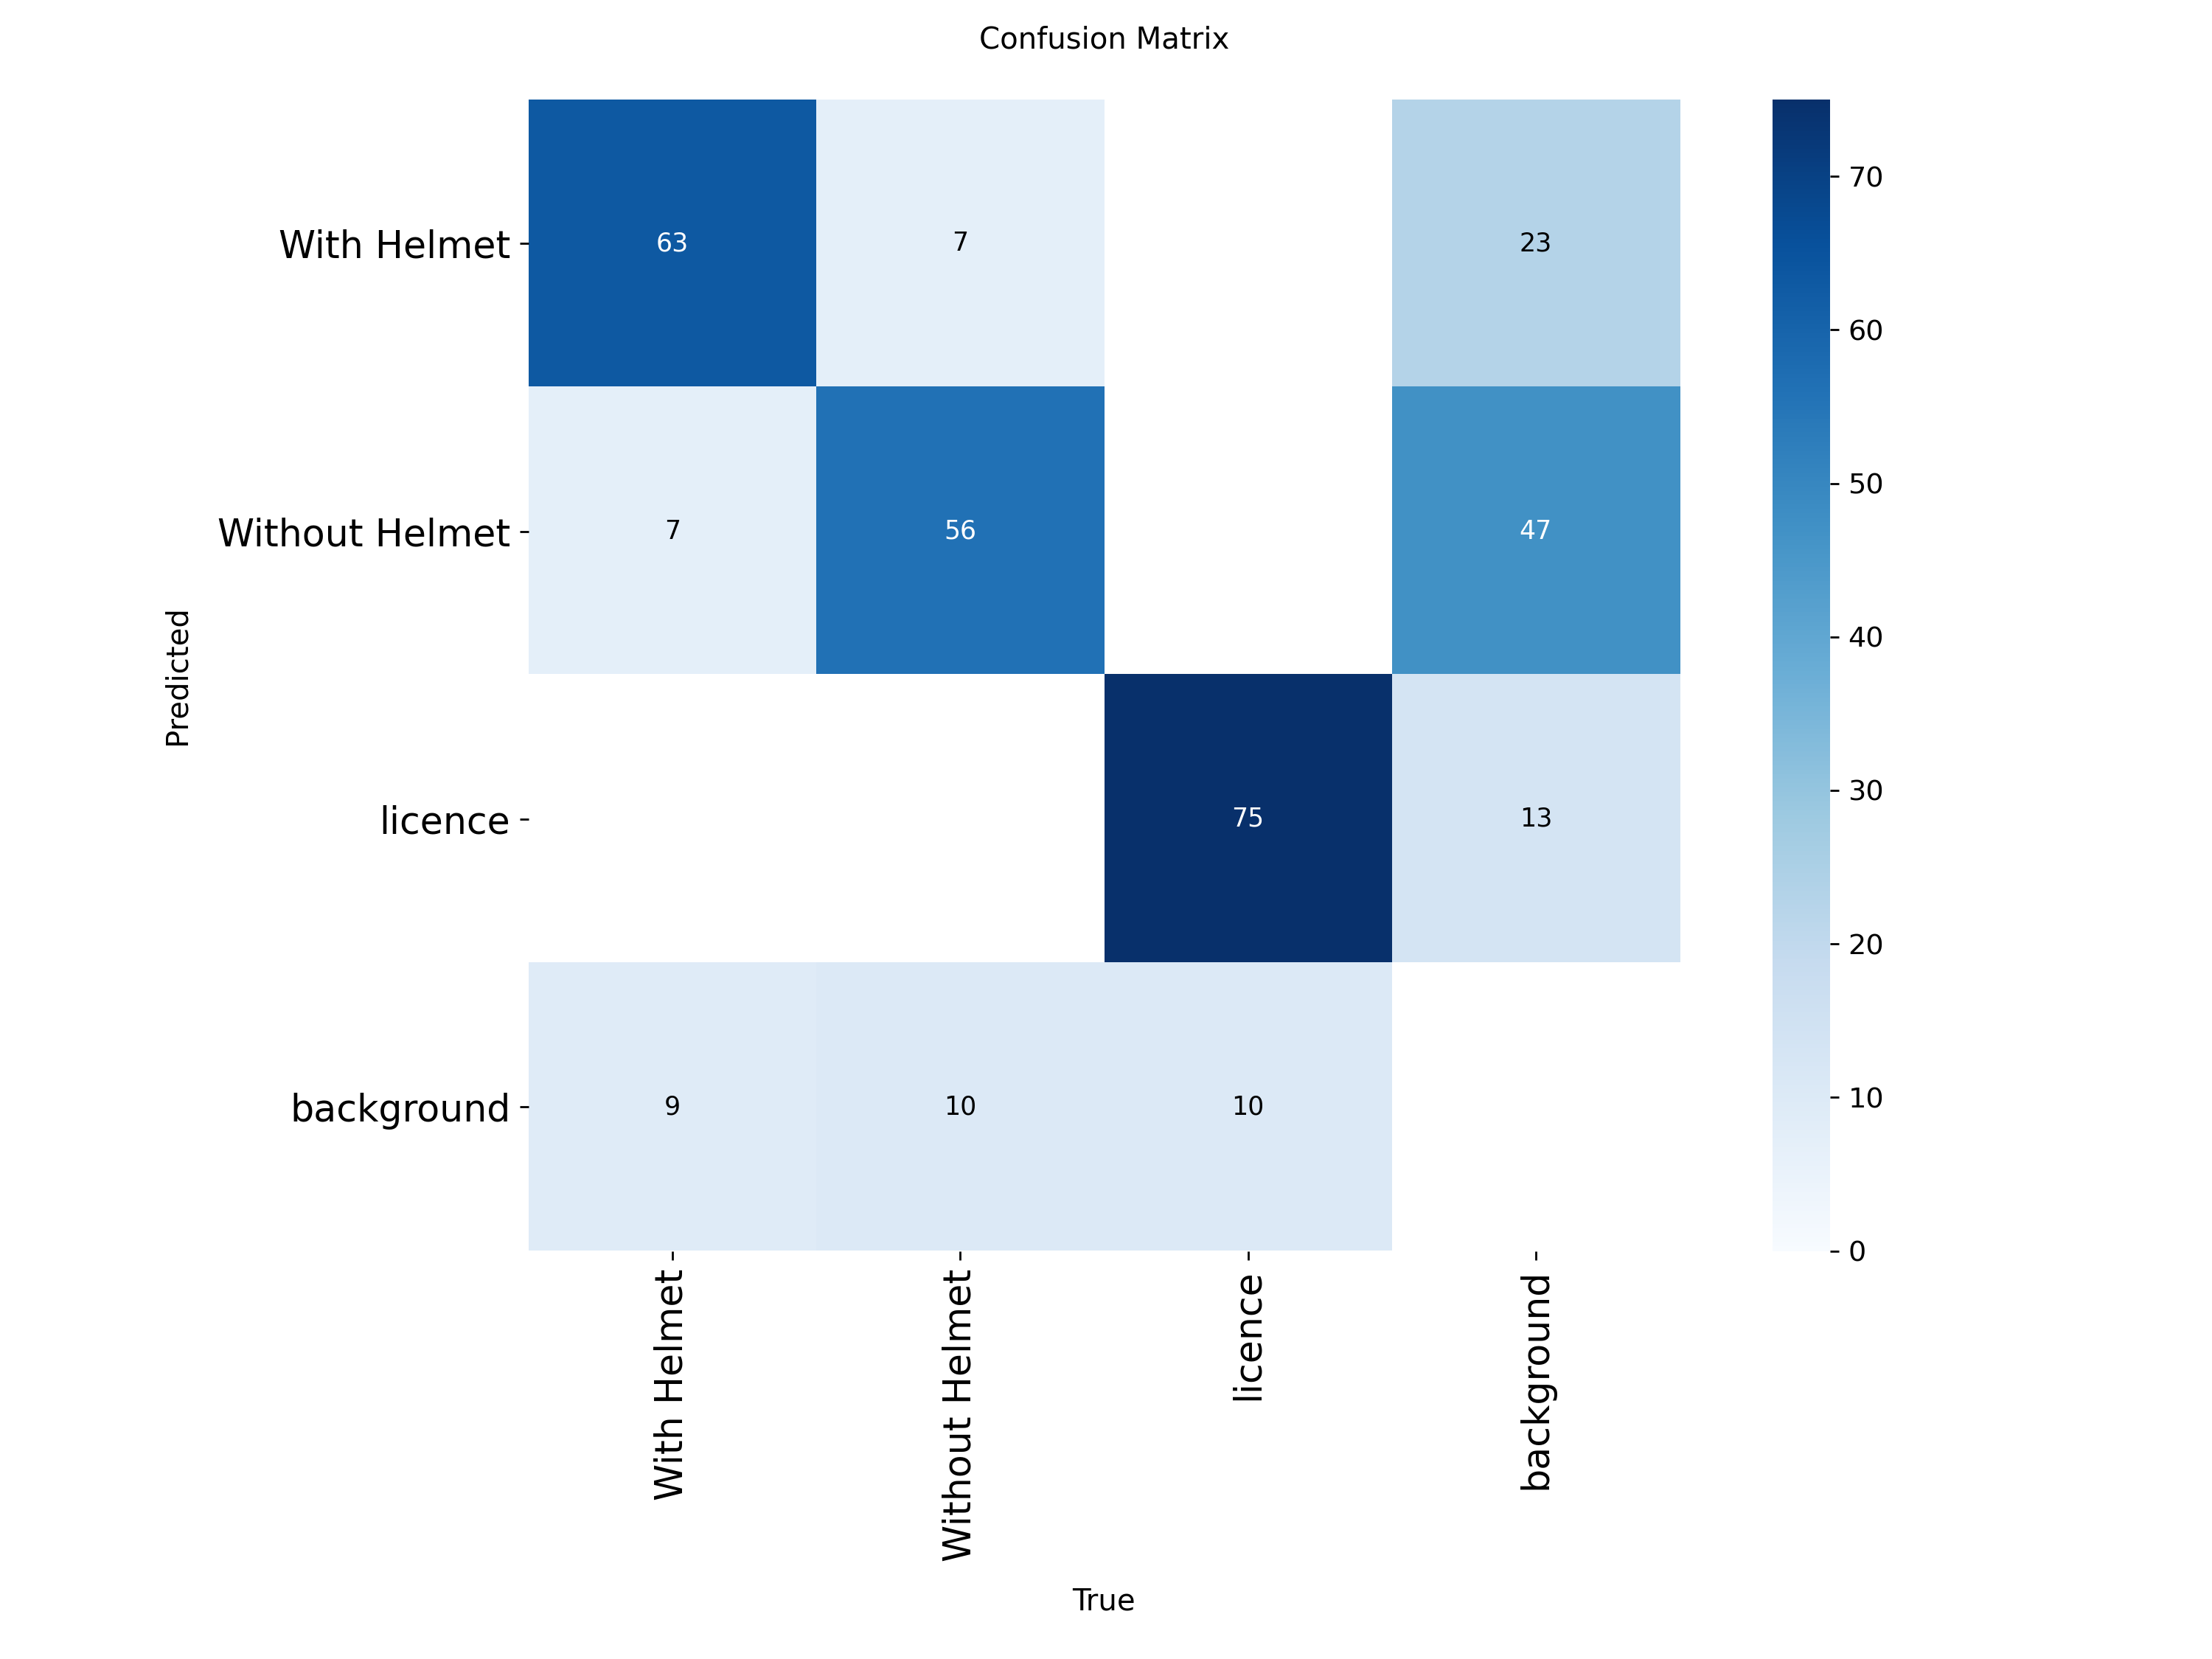

confusion_matrix_normalized.png


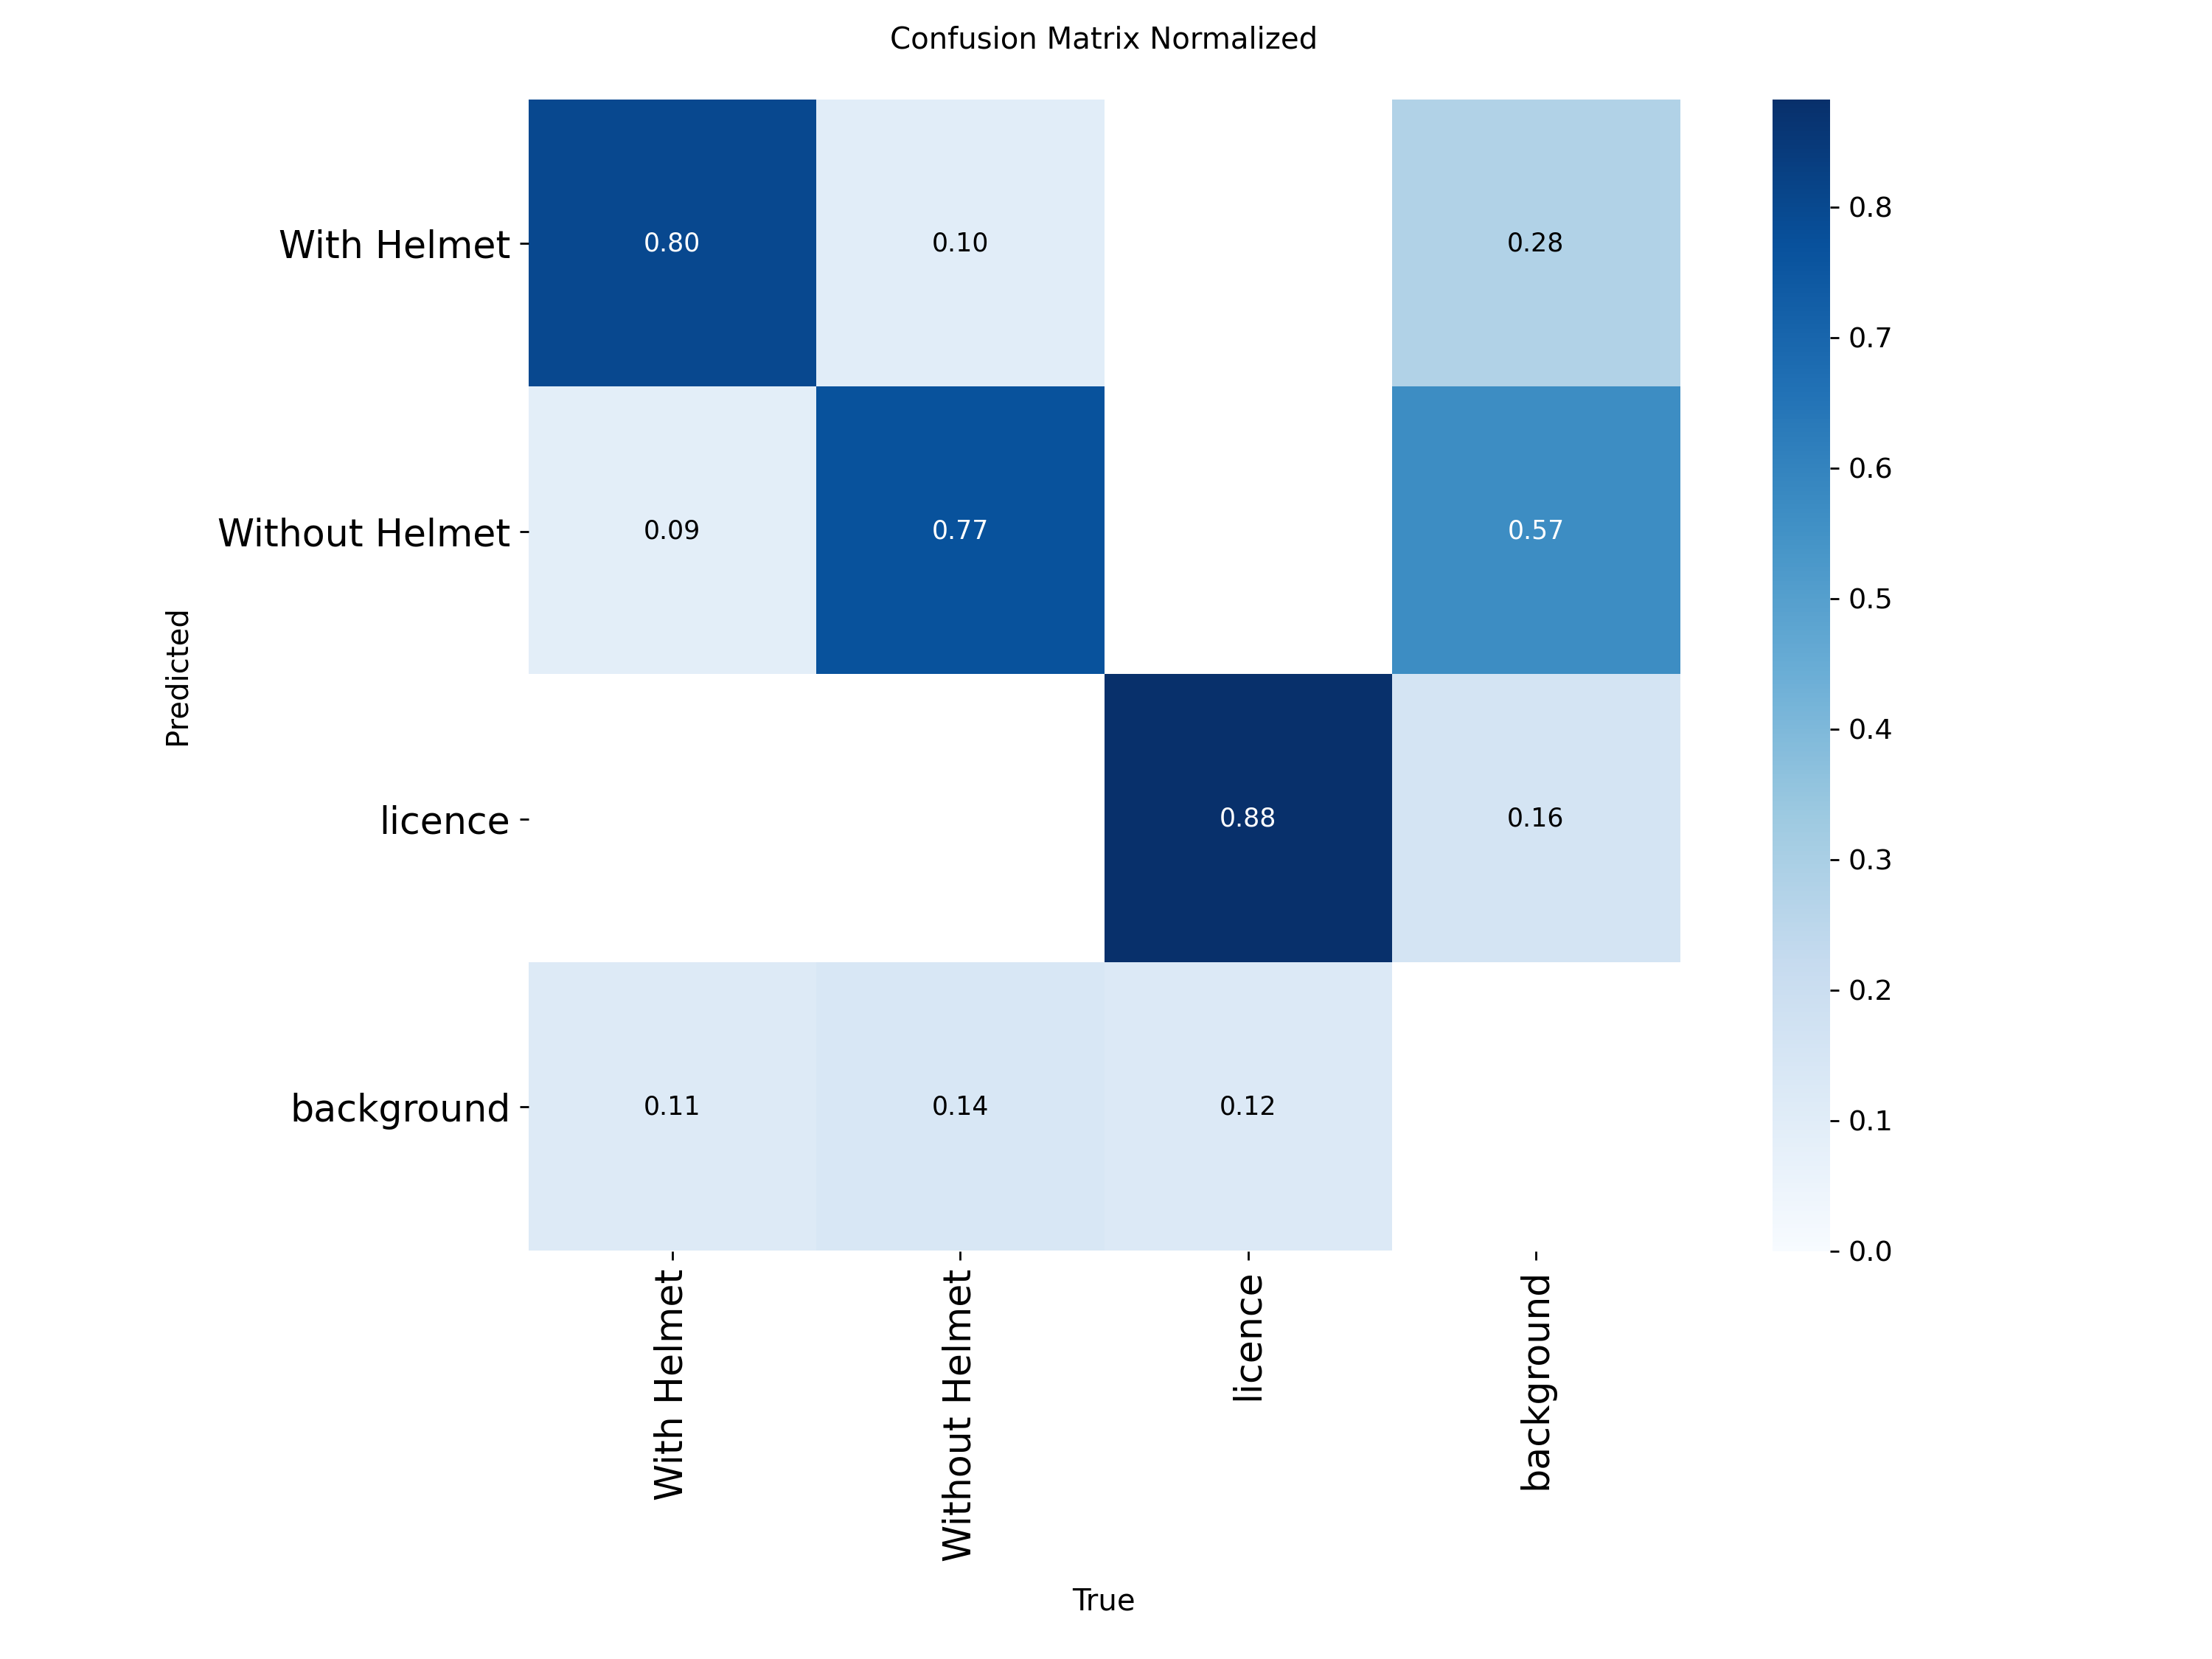

BoxPR_curve.png


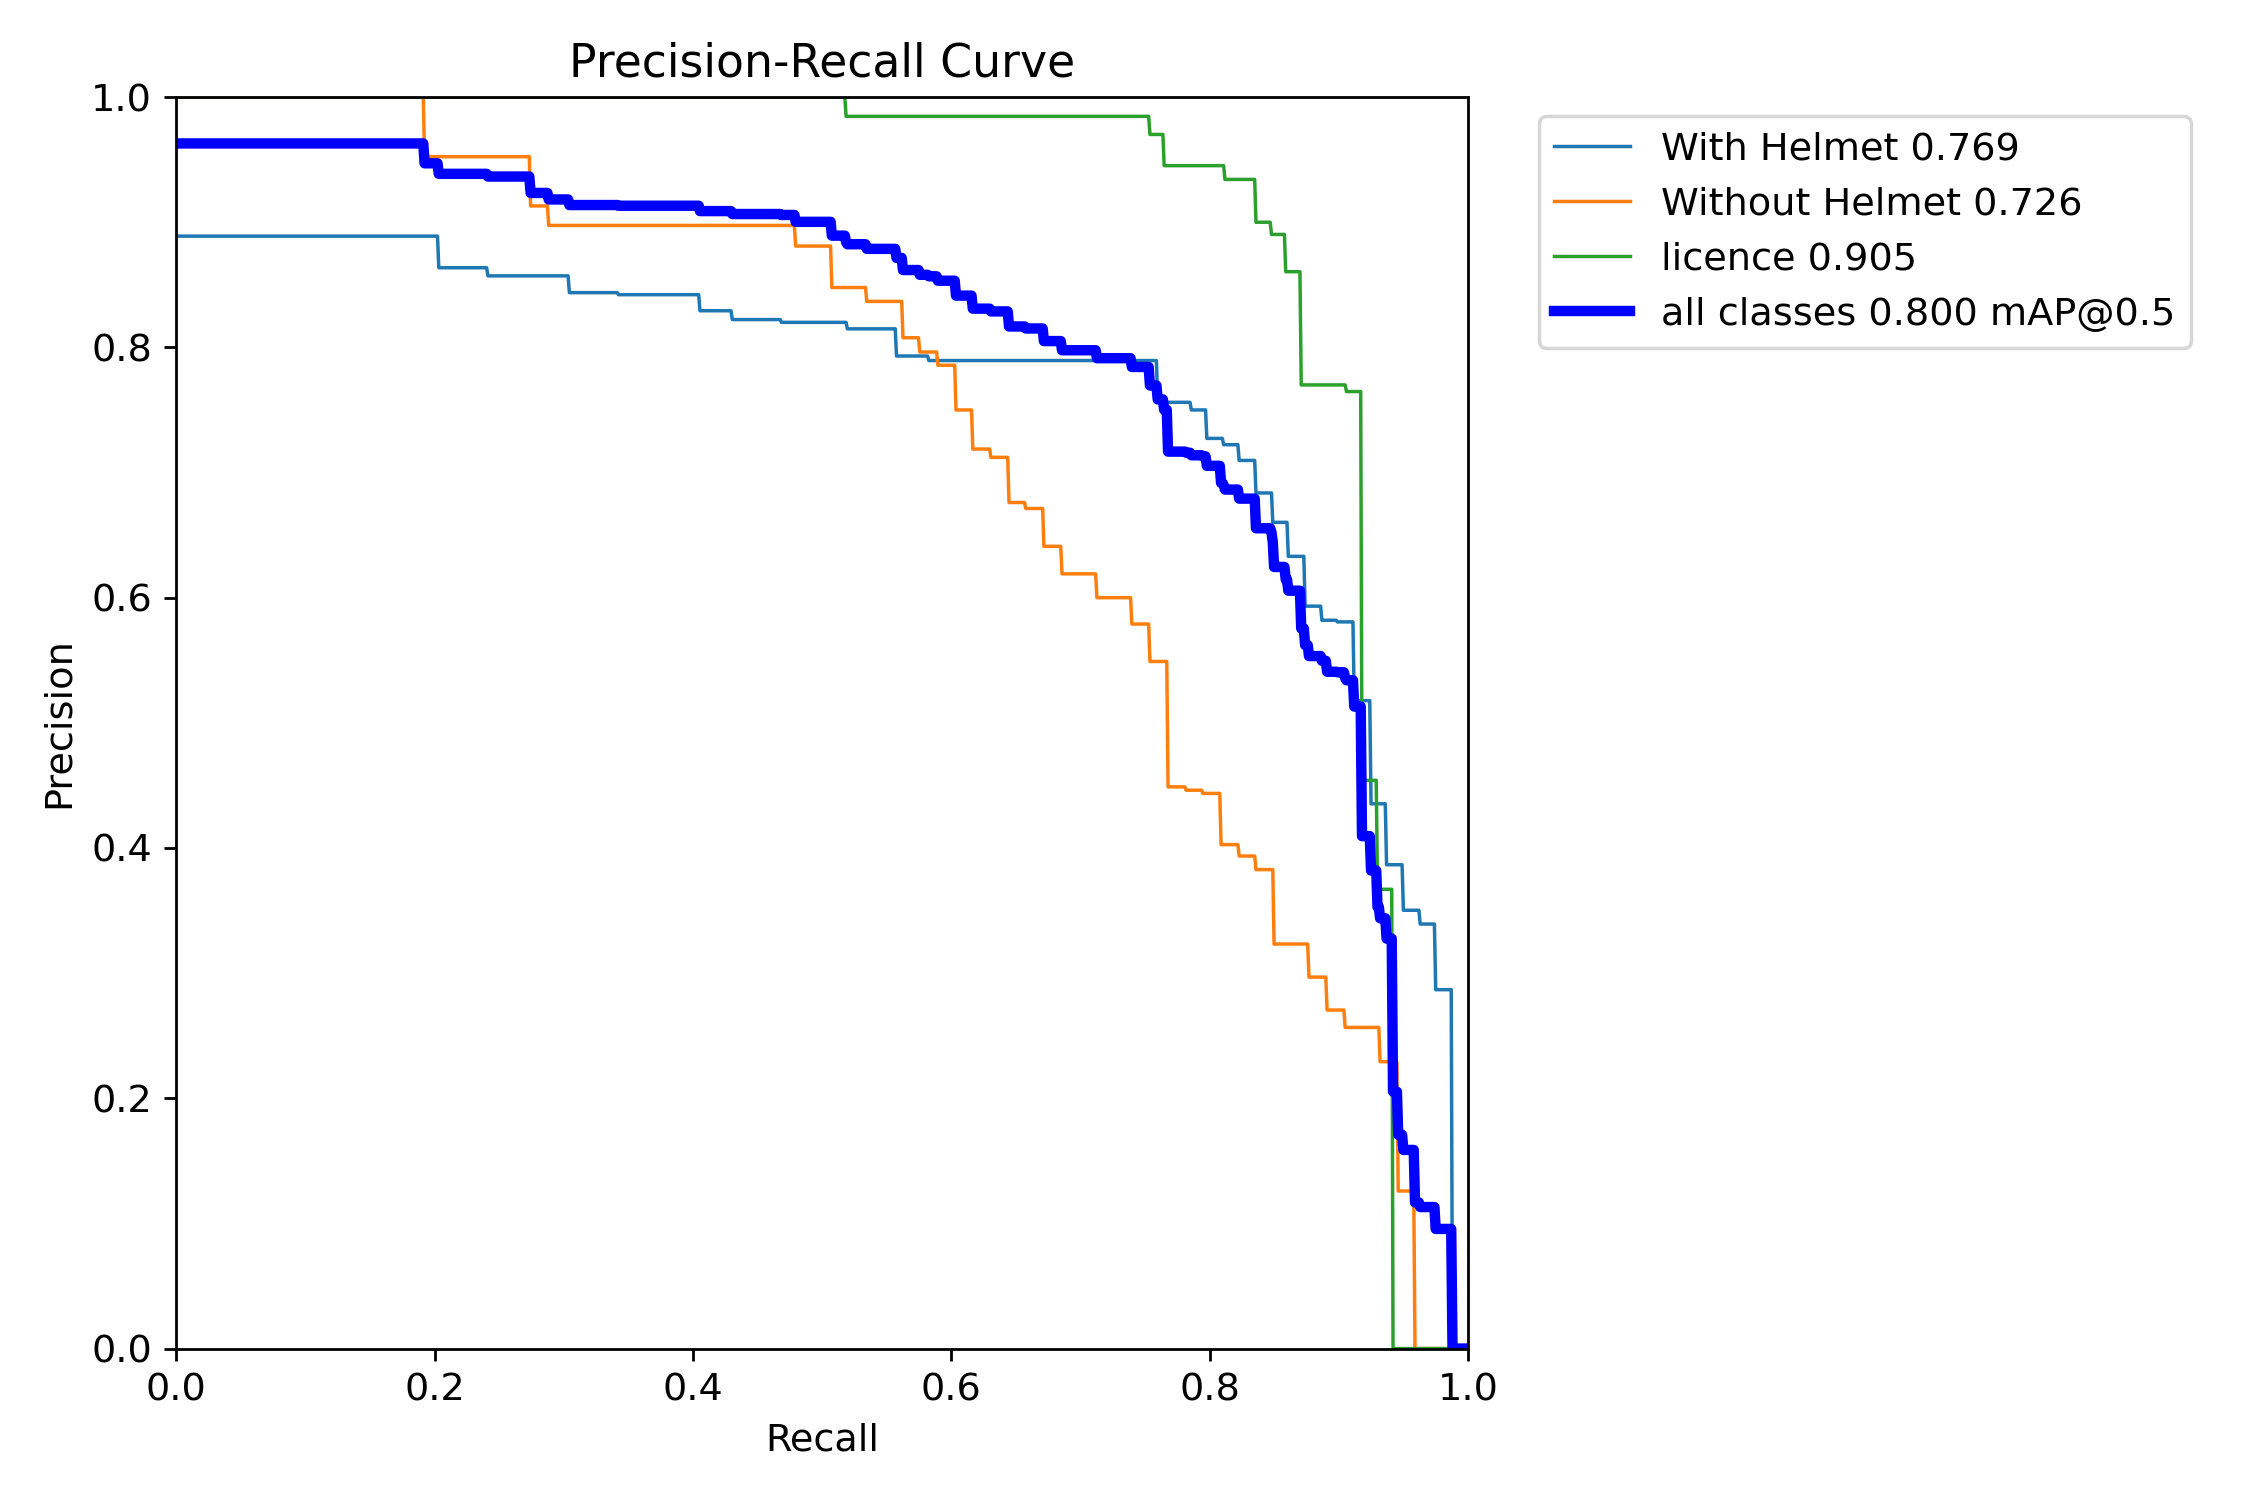

BoxP_curve.png


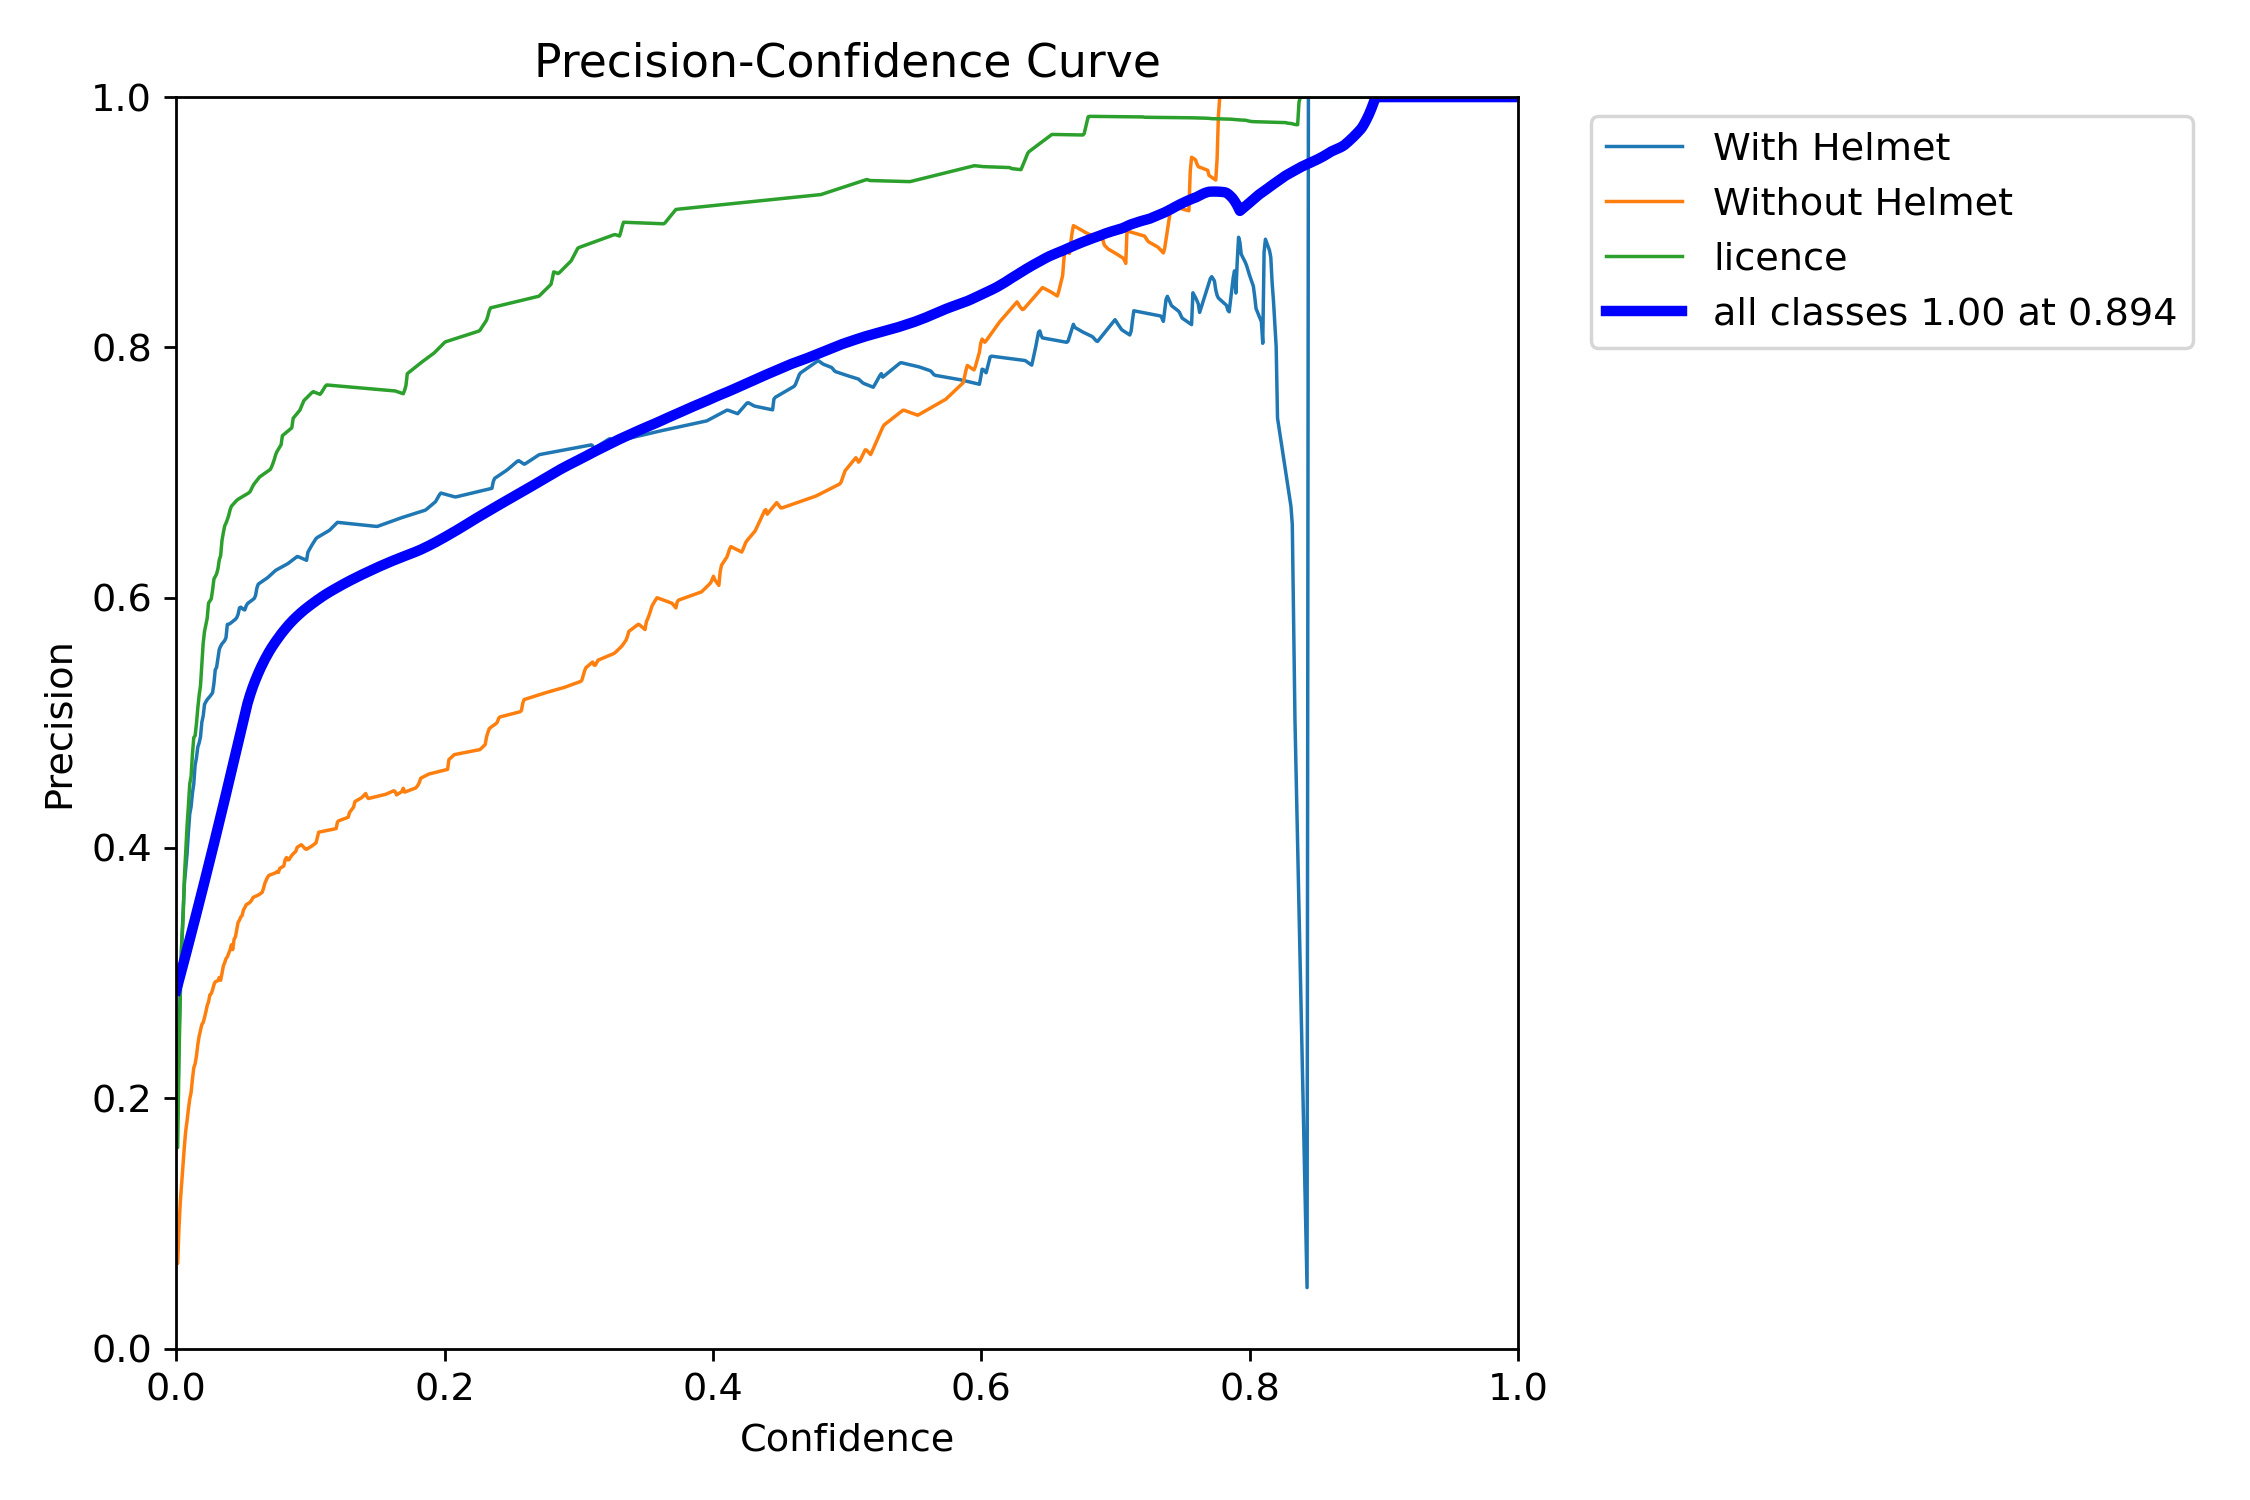

BoxR_curve.png


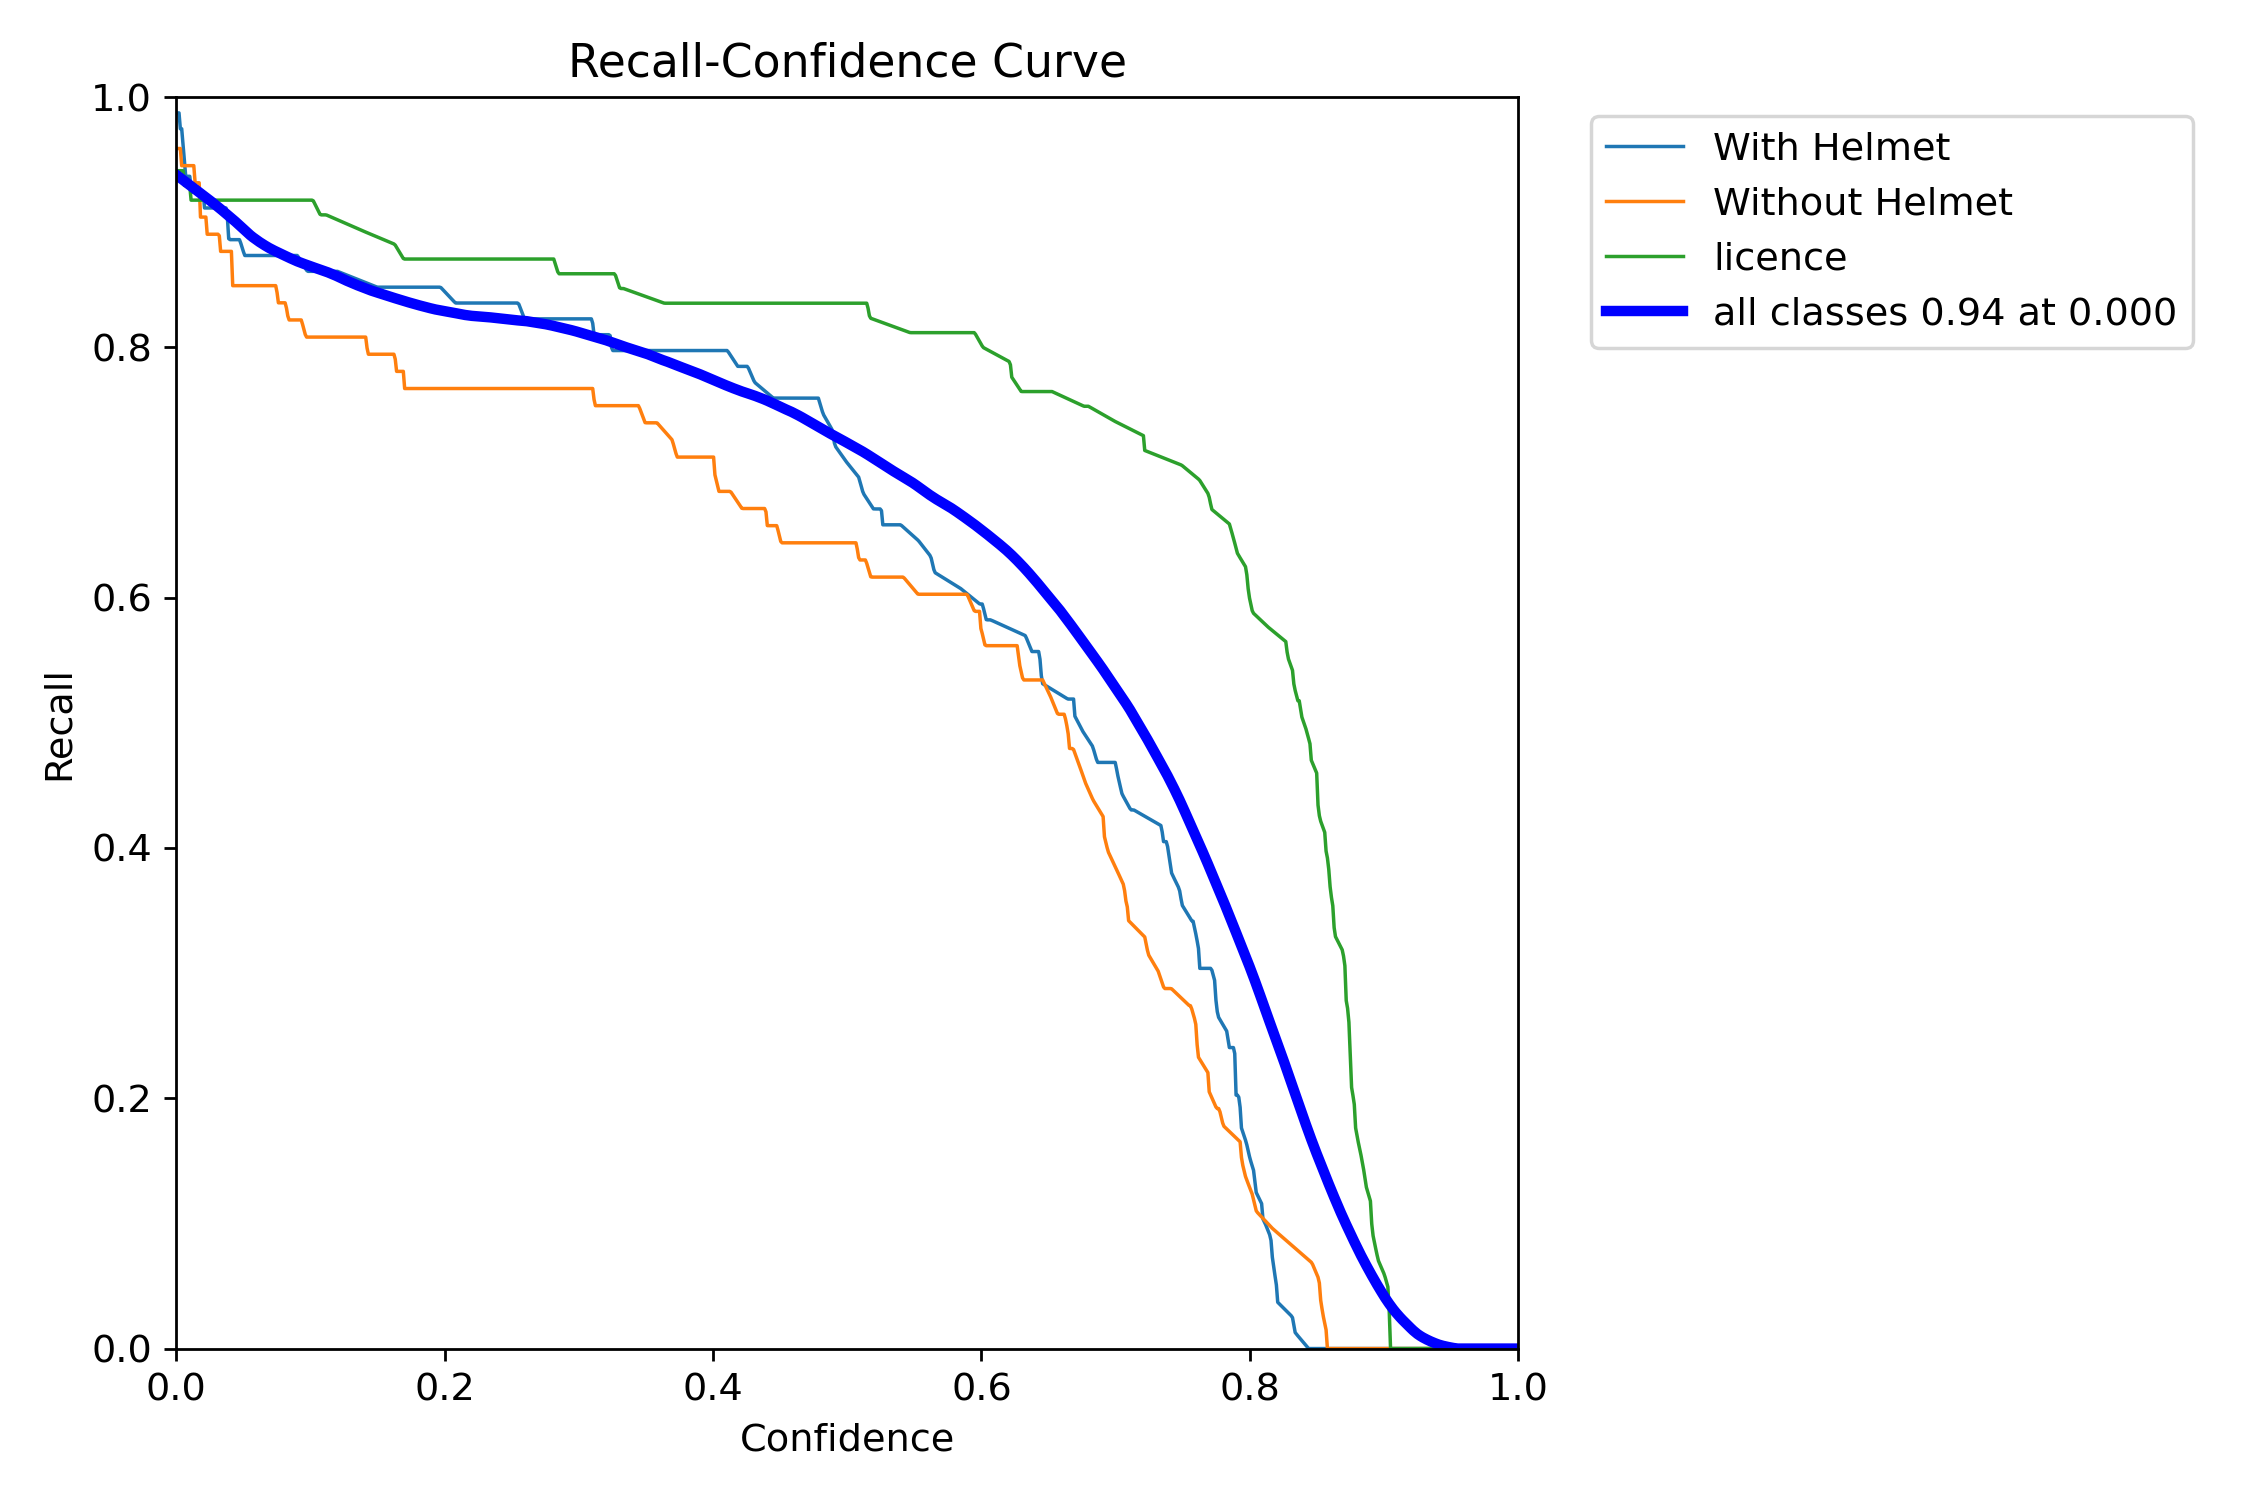

BoxF1_curve.png


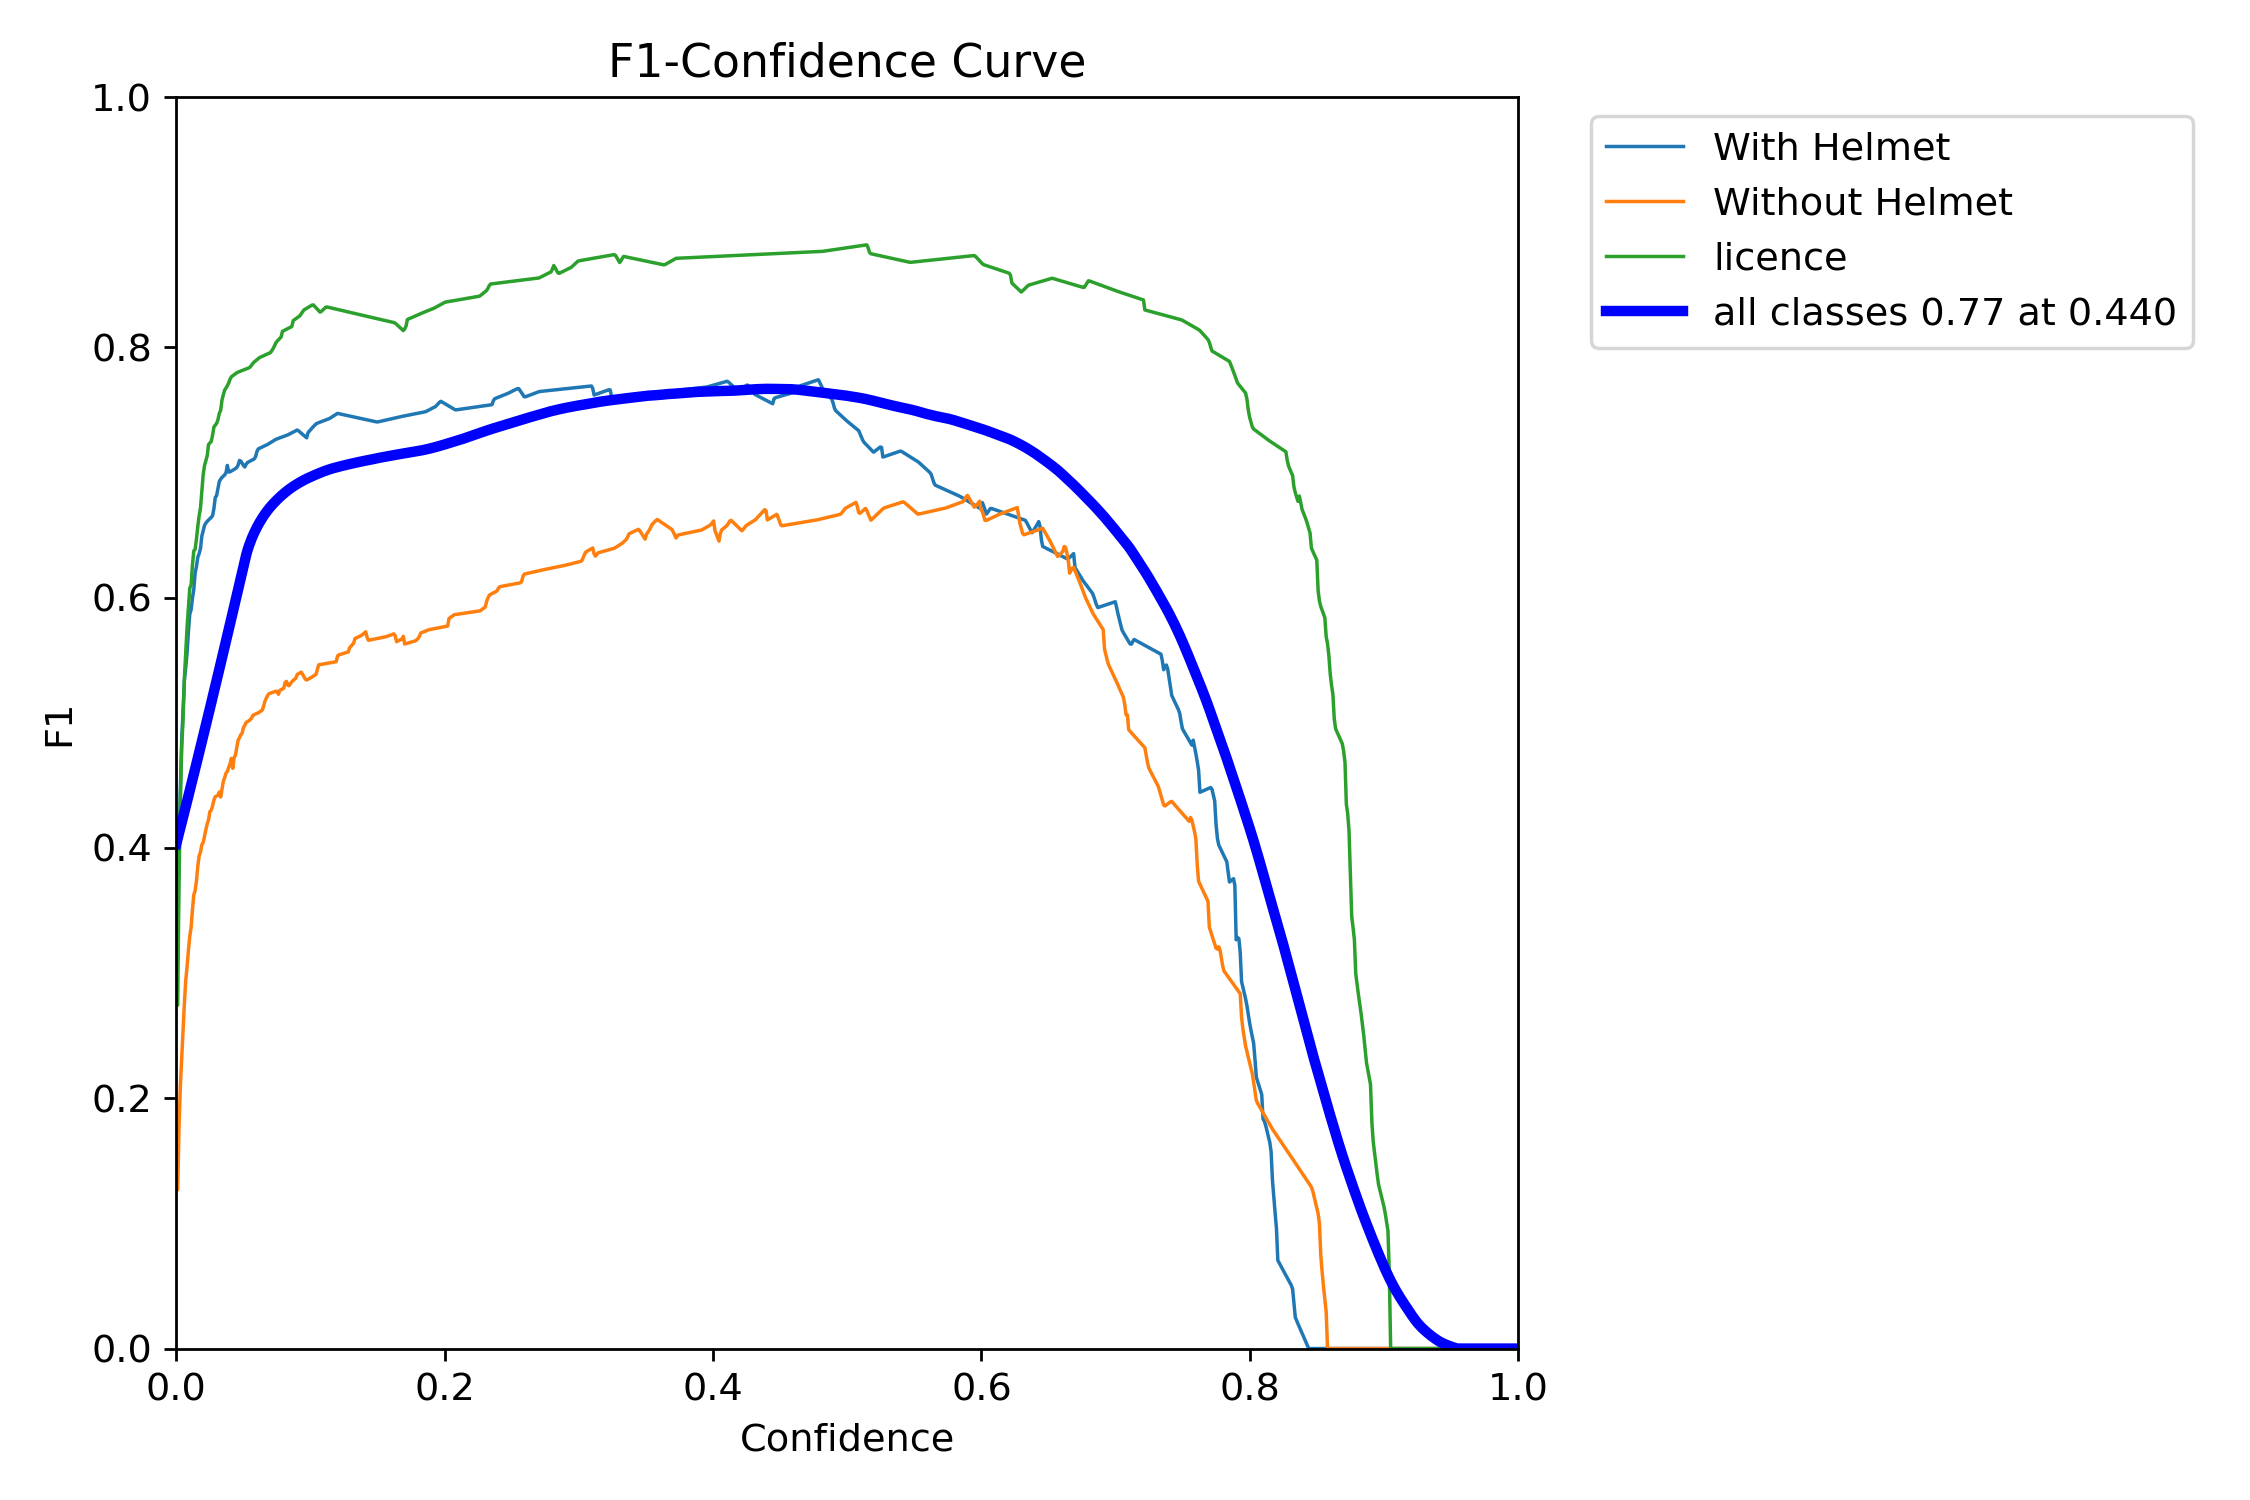

In [16]:
from IPython.display import Image, display
import os

plot_files = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "BoxF1_curve.png"
]

for file in plot_files:
    path = os.path.join(str(metrics.save_dir), file)
    if os.path.exists(path):
        print(file)
        display(Image(filename=path, width=800))

# Conclusion

This project implemented a custom YOLOv8 object detection model for detecting helmet usage and licence plates in images. The dataset contained three classes: With Helmet, Without Helmet, and licence.

The YOLOv8n model was trained for 50 epochs and evaluated on 154 unseen test images. The model achieved a Precision of 77.85%, Recall of 75.21%, mAP@50 of 80.00%, and mAP@50–95 of 46.74%.

The detection results demonstrate that the trained model can identify the target objects in test images. The model achieved its highest per-class mAP@50 for the licence class (90.50%), while the Without Helmet class had a lower mAP@50 (72.60%), indicating that distinguishing helmet status was more challenging for this dataset.

Overall, the project demonstrates the use of YOLOv8 for a practical computer vision object detection problem involving road-safety-related objects.